# Google Colab R

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


## Demonstration

This notebook uses the R kernel.


In [166]:
library(ggplot2)
library(tidyverse)
library(dplyr)
library(readr)


In [167]:
HREmployeeDF <- read.csv2("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [168]:
head(HREmployeeDF)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2
6,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,⋯,3,80,0,8,2,2,7,7,3,6


In [169]:
summary(HREmployeeDF)

      Age            Attrition      BusinessTravel   DailyRate     
 Min.   :18.00   Length   :1470   Length   :1470   Min.   : 102.0  
 1st Qu.:30.00   N.unique :   2   N.unique :   3   1st Qu.: 465.0  
 Median :36.00   N.blank  :   0   N.blank  :   0   Median : 802.0  
 Mean   :36.92   Min.nchar:   2   Min.nchar:  10   Mean   : 802.5  
 3rd Qu.:43.00   Max.nchar:   3   Max.nchar:  17   3rd Qu.:1157.0  
 Max.   :60.00                                     Max.   :1499.0  
     Department   DistanceFromHome   Education       EducationField
 Length   :1470   Min.   : 1.000   Min.   :1.000   Length   :1470  
 N.unique :   3   1st Qu.: 2.000   1st Qu.:2.000   N.unique :   6  
 N.blank  :   0   Median : 7.000   Median :3.000   N.blank  :   0  
 Min.nchar:   5   Mean   : 9.193   Mean   :2.913   Min.nchar:   5  
 Max.nchar:  22   3rd Qu.:14.000   3rd Qu.:4.000   Max.nchar:  16  
                  Max.   :29.000   Max.   :5.000                   
 EmployeeCount EmployeeNumber   EnvironmentSatis

**1.0 - Analise da satisfação laboral do trabalhador consoante a idade e genero.**

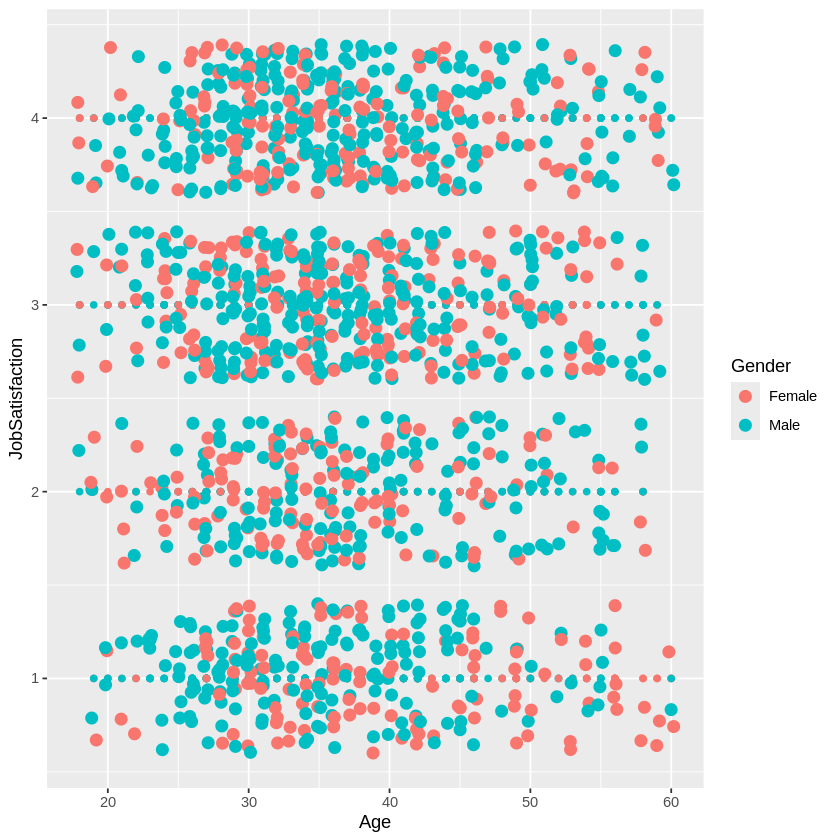

In [170]:
HREmployeeDF %>%
ggplot(aes(Age,JobSatisfaction, color=Gender))+
geom_point(alpha=1) +geom_jitter(width = 0.20, alpha = 2, size = 3) +
  theme_get()

**1.1 - Analise da satisfação laboral do trabalhador consoante a idade e genero.**


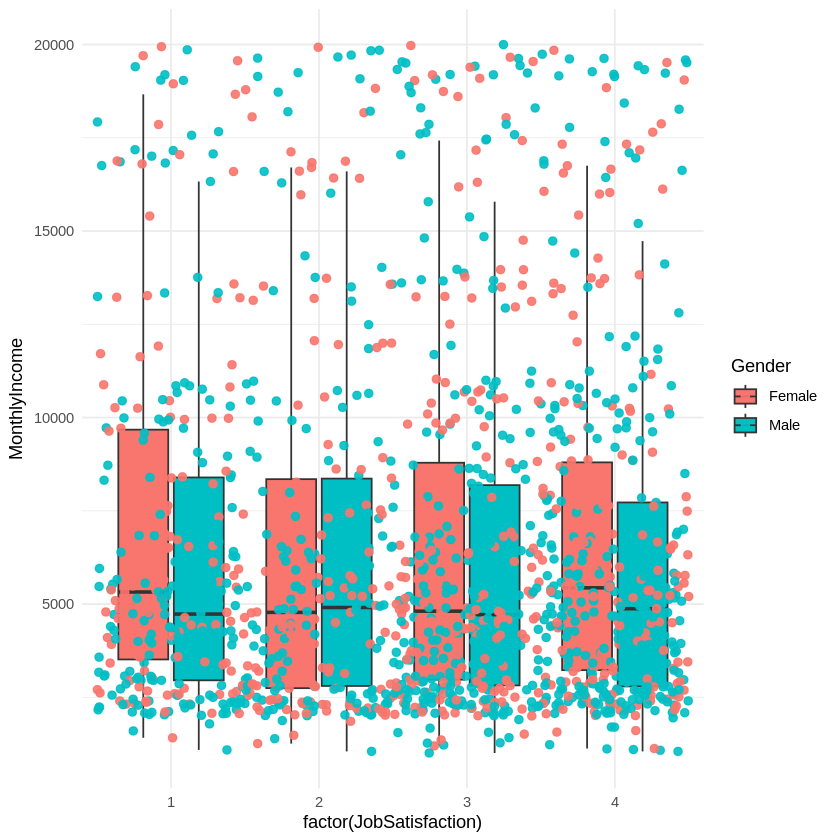

In [171]:
HREmployeeDF %>%
  ggplot(aes(x = factor(JobSatisfaction),
             y = MonthlyIncome,
             fill = Gender)) +
  geom_boxplot(alpha = 1, outlier.shape = NA) +
  geom_jitter(aes(color = Gender),
              width = 0.50,
              alpha = 0.9,
              size = 2) +
  theme_minimal()

**2.0 - Analise Salarial consoante a formação do trabalhador.**

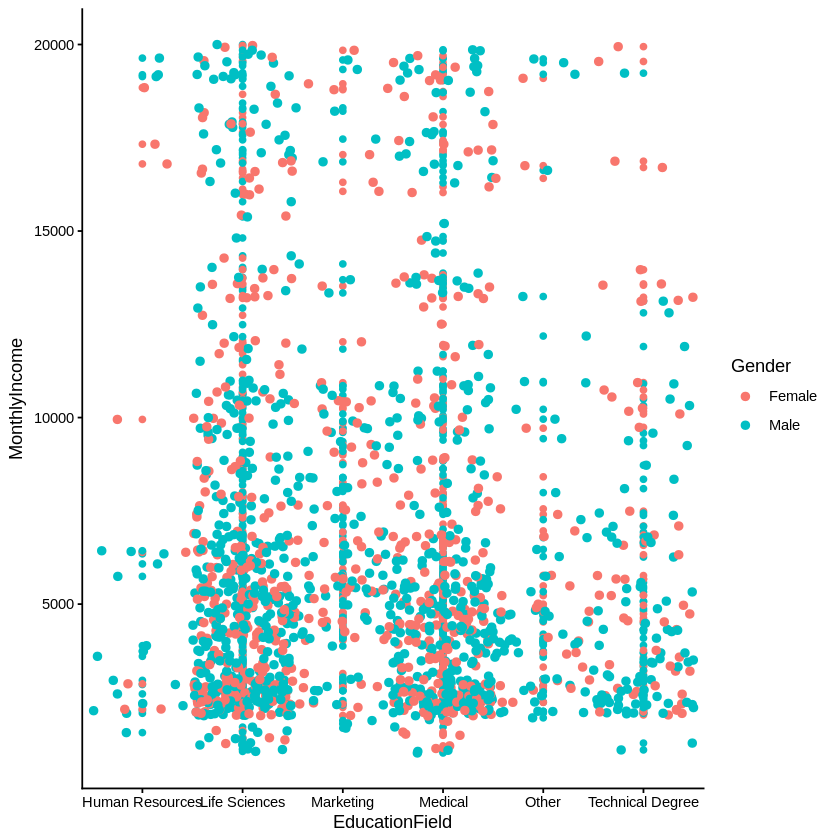

In [172]:
HREmployeeDF %>%
ggplot(aes( EducationField,MonthlyIncome, color=Gender))+
geom_point(alpha=1) + geom_jitter(width = 0.5, alpha = 8, size =2) +
  theme_classic()

**2.1- Analise Salarial consoante as horas acumuladas de trabalho.**

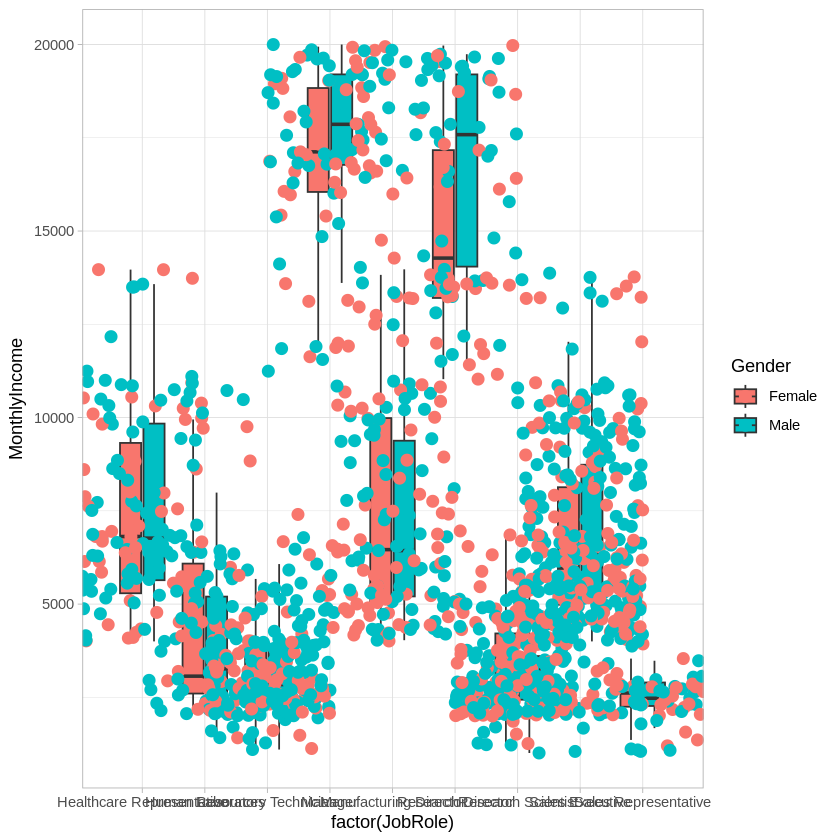

In [173]:
HREmployeeDF %>%
  ggplot(aes(x = factor(JobRole),
             y = MonthlyIncome,
             fill = Gender)) +
  geom_boxplot(alpha = 5, outlier.shape = NA) +
  geom_jitter(aes(color = Gender),
              width = 1,
              alpha = 1,
              size = 3) +
  theme_light()

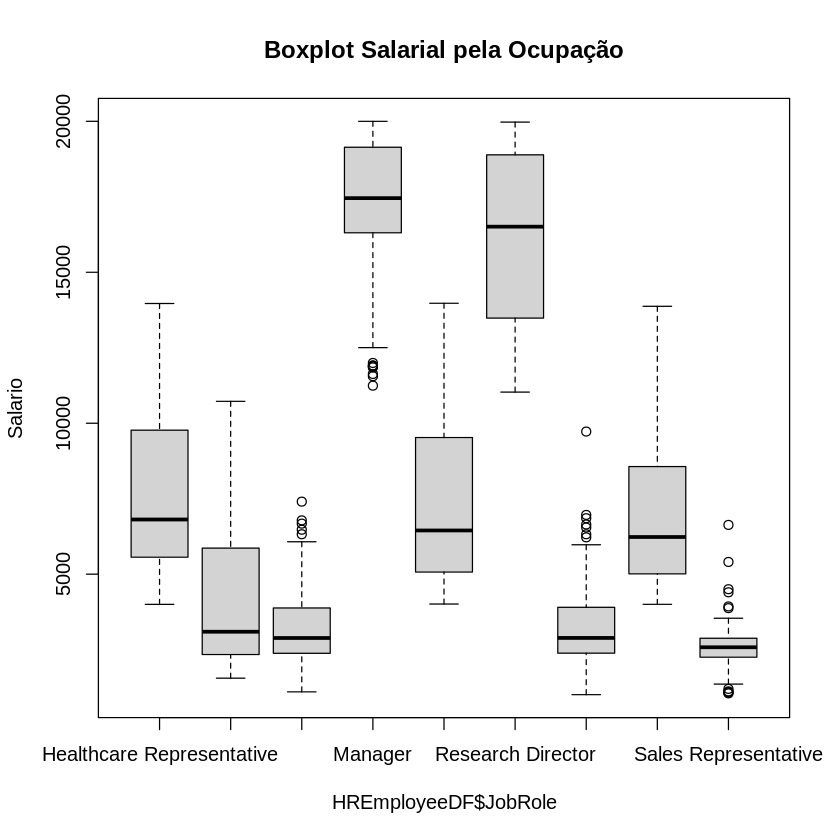

In [175]:
boxplot(HREmployeeDF$MonthlyIncome ~ HREmployeeDF$JobRole, main = "Boxplot Salarial pela Ocupação",ylab = "Salario")

**3.0 - Disparidade Salarial. **

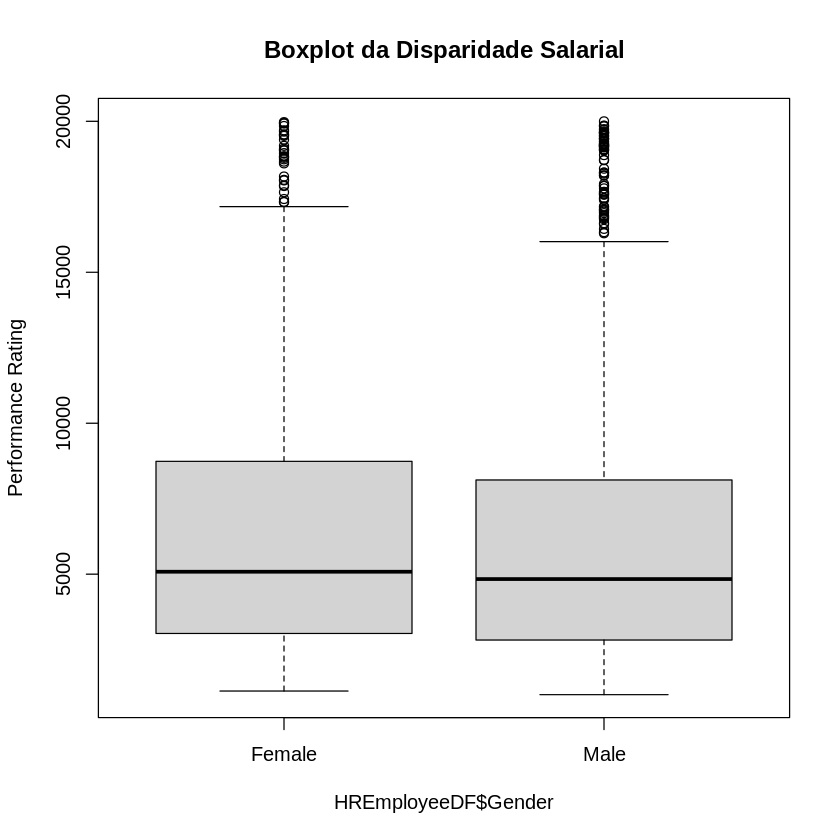

In [176]:
boxplot(HREmployeeDF$MonthlyIncome ~ HREmployeeDF$Gender, main = "Boxplot da Disparidade Salarial",ylab = "Performance Rating")

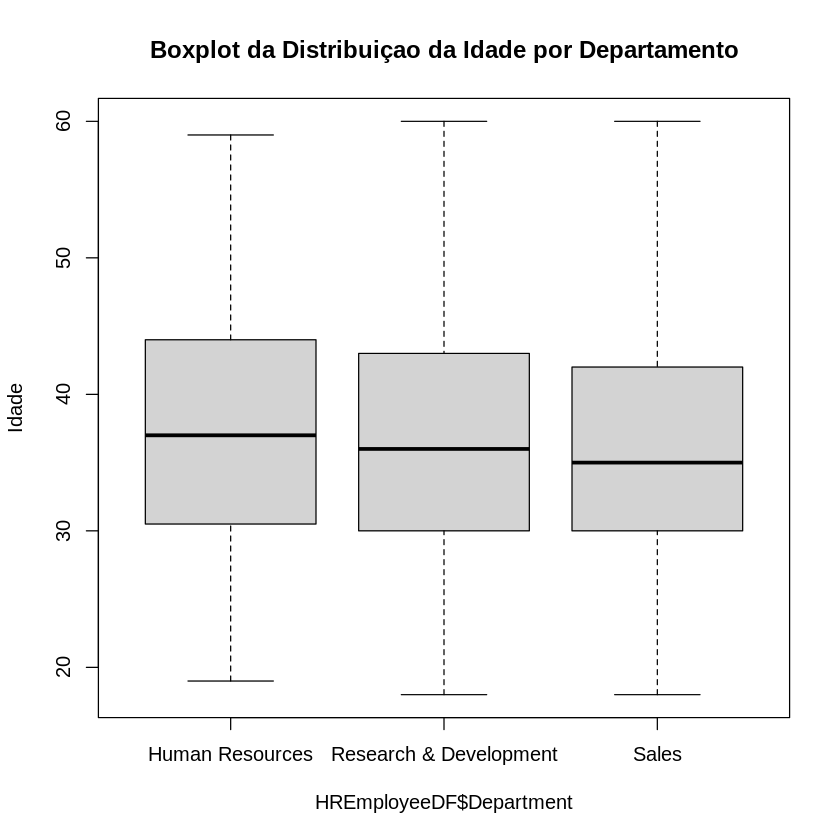

In [177]:
boxplot(HREmployeeDF$Age ~ HREmployeeDF$Department, main = "Boxplot da Distribuiçao da Idade por Departamento",ylab = "Idade")

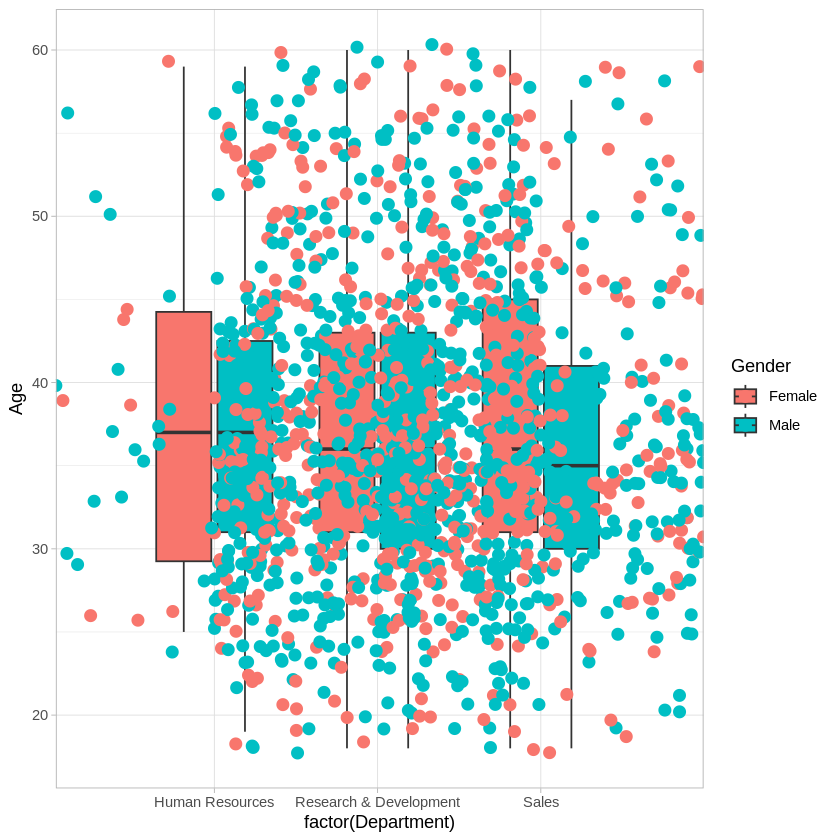

In [178]:
HREmployeeDF %>%
  ggplot(aes(x = factor(Department),
             y = Age,
             fill = Gender)) +
  geom_boxplot(alpha = 5, outlier.shape = NA) +
  geom_jitter(aes(color = Gender),
              width = 1,
              alpha = 1,
              size = 3) +
  theme_light()

**4.0 - Analise da Performance dos trabalhadores.**

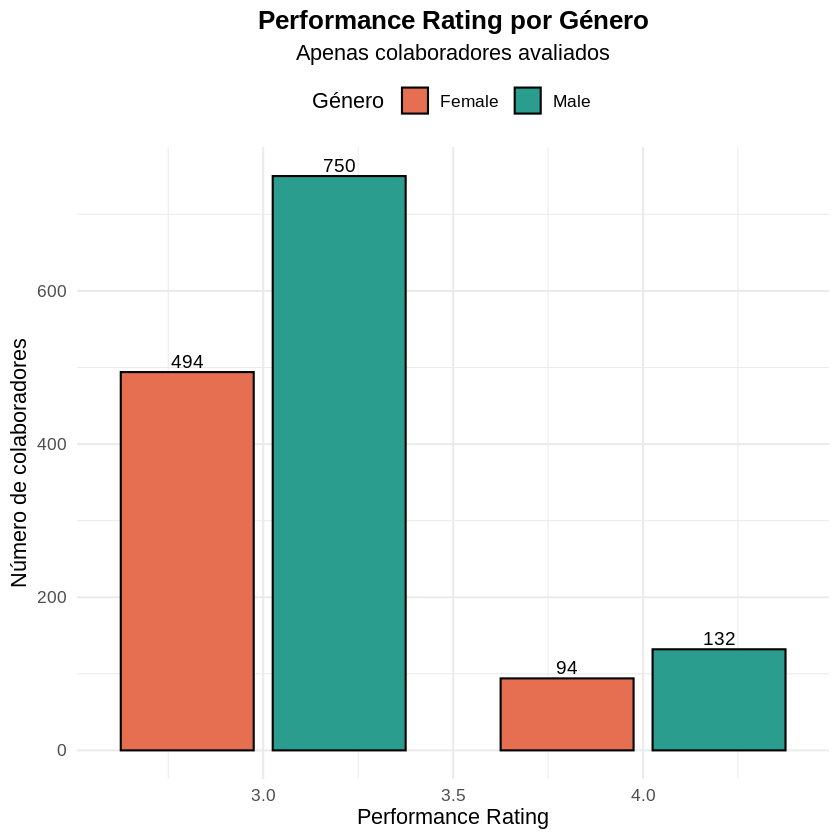

In [179]:

Performance_Gender <- HREmployeeDF %>%
  filter(PerformanceRating != "N/A- too early to review") %>%
  count(Gender, PerformanceRating, name = "EmployeeNumber")

ggplot(Performance_Gender,
       aes(x = PerformanceRating,
           y = EmployeeNumber,
           fill = Gender)) +
  geom_col(position = position_dodge(width = 0.8),
           width = 0.7,
           color = "black") +
  geom_text(aes(label = EmployeeNumber),
            position = position_dodge(width = 0.8),
            vjust = -0.3,
            size = 4) +
  scale_fill_manual(values = c("Female" = "#E76F51",
                               "Male" = "#2A9D8F")) +
  labs(
    title = "Performance Rating por Género",
    subtitle = "Apenas colaboradores avaliados",
    x = "Performance Rating",
    y = "Número de colaboradores",
    fill = "Género"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5),
    legend.position = "top"
  )

**4.1 - Analise da Performance em Percentagem dos trabalhadores.**

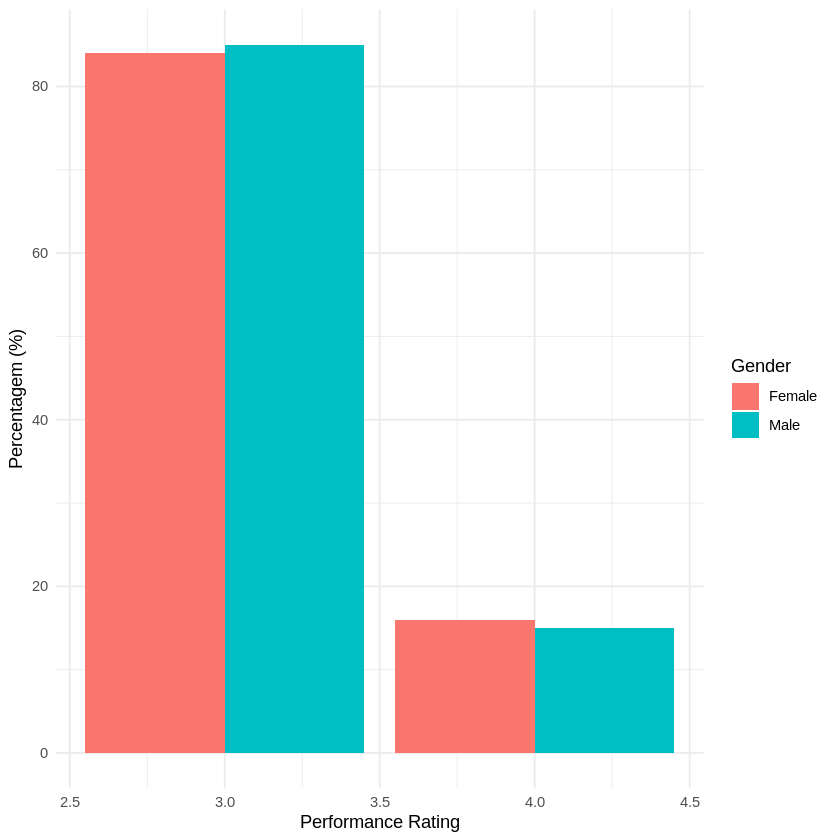

In [180]:
Performance_Gender %>%
  group_by(Gender) %>%
  mutate(Percent = EmployeeNumber / sum(EmployeeNumber) * 100) %>%
  ggplot(aes(x = PerformanceRating,
             y = Percent,
             fill = Gender)) +
  geom_col(position = "dodge") +
  labs(
    x = "Performance Rating",
    y = "Percentagem (%)",
    fill = "Gender"
  ) +
  theme_minimal()

**5.0 - Analise do Salario Medio por Função.**

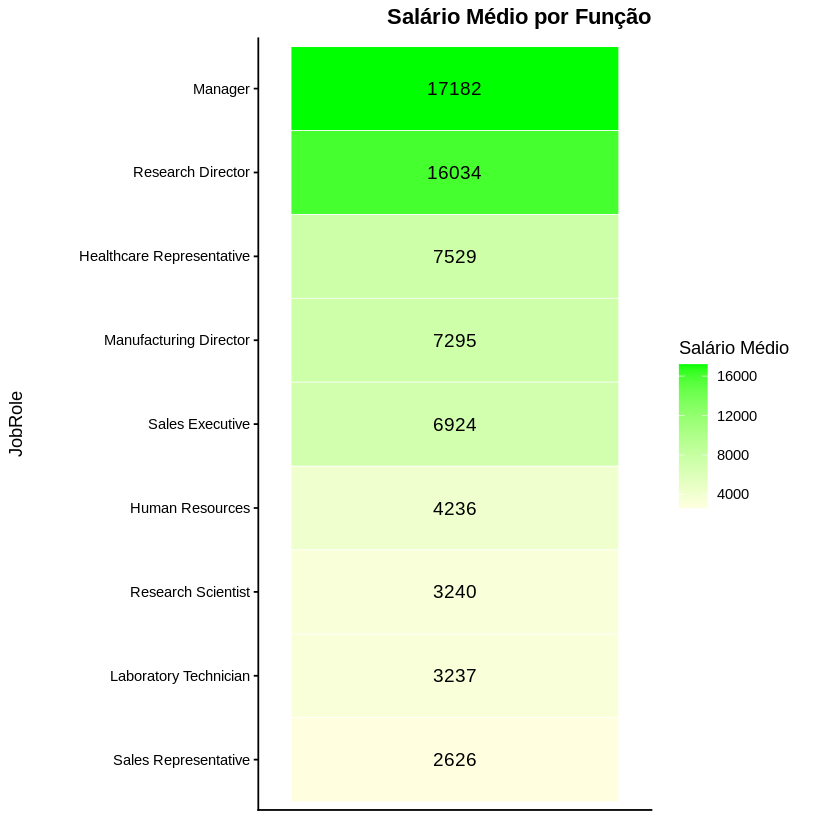

In [181]:

HREmployeeDF %>%
  group_by(JobRole) %>%
  summarise(MeanIncome = mean(MonthlyIncome, na.rm = TRUE),
            .groups = "drop") %>%
  ggplot(aes(x = "", y = reorder(JobRole, MeanIncome), fill = MeanIncome)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(MeanIncome, 0)), color = "black", size = 4) +
  scale_fill_gradient(low = "lightyellow", high = "green") +
  labs(
    title = "Salário Médio por Função",
    x = "",
    y = "JobRole",
    fill = "Salário Médio"
  ) +
  theme_classic() +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.title = element_text(face = "bold", hjust = 1)
  )

**5.1 - Analise do Salario Medio por Funçao e Genero.**

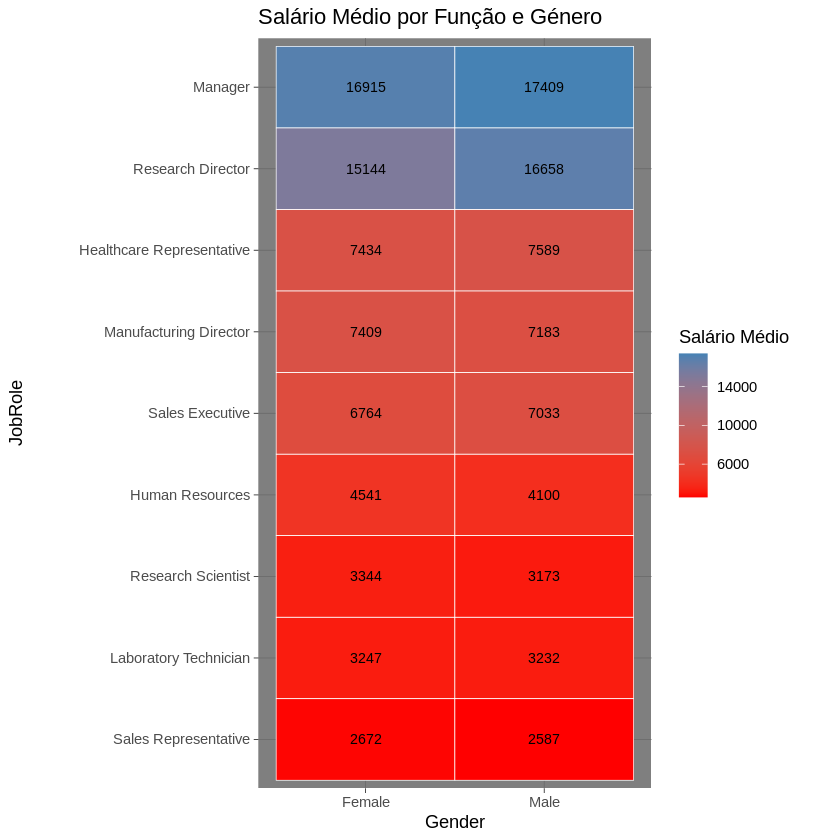

In [182]:
HREmployeeDF %>%
  group_by(JobRole, Gender) %>%
  summarise(MeanIncome = mean(MonthlyIncome, na.rm = TRUE),
            .groups = "drop") %>%
  ggplot(aes(x = Gender,
             y = reorder(JobRole, MeanIncome),
             fill = MeanIncome)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(MeanIncome, 0)), size = 3) +
  scale_fill_gradient(low = "red", high = "steelblue") +
  labs(
    title = "Salário Médio por Função e Género",
    x = "Gender",
    y = "JobRole",
    fill = "Salário Médio"
  ) +
  theme_dark()